In [1]:
import torch
from cheetah.particles import ParticleBeam
from cheetah.accelerator import Solenoid, Drift, Segment

In [2]:
# initial particle coordinates: x, px, y, py, z, pz, t
x0 = torch.tensor([1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]) * 1e-3  # 1 mm offset in x and y
x0 = x0.unsqueeze(0)  # shape (1,7)

test_beam = ParticleBeam(x0, energy=torch.tensor(5e6))

In [3]:
# create solenoid element
solenoid = Solenoid(
    length=torch.tensor(1.0),  # 1.0 m long solenoid
)

# set focusing strength scan range
n_steps = 10
scan_range = torch.linspace(0.0, 1.0, n_steps)  # 0.0 T to 1 T

solenoid.k = scan_range


# define lattice
lattice = Segment(elements=[solenoid, Drift(length=torch.tensor(1.0))])

In [4]:
# track beam
final_beam = lattice.track(test_beam)

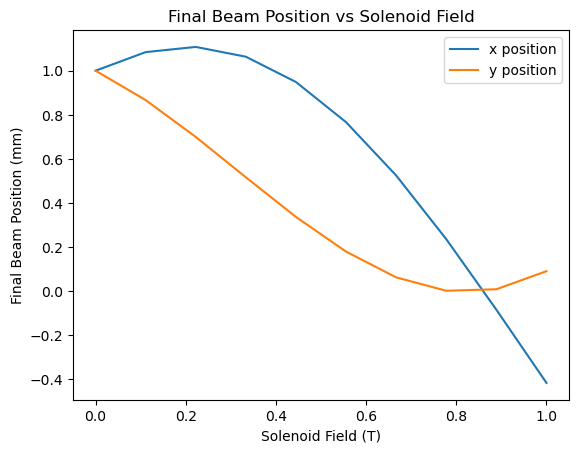

In [5]:
# plot final beam location as a function of solenoid field
import matplotlib.pyplot as plt

plt.plot(scan_range.numpy(), final_beam.x.numpy() * 1e3, label="x position")
plt.plot(scan_range.numpy(), final_beam.y.numpy() * 1e3, label="y position")

plt.xlabel("Solenoid Field (T)")
plt.ylabel("Final Beam Position (mm)")
plt.title("Final Beam Position vs Solenoid Field")
plt.legend()
plt.show()

In [6]:
# define a function that takes in a beam location and solenoid field and returns the final beam location
# put into a form such that it can be used in Xopt


def compute_final_beam_position(inputs):
    solenoid_field = inputs["solenoid_field"]
    initial_beam_x = inputs["initial_beam_x"]*1e-3 # initial x centroid in meters
    initial_beam_y = inputs["initial_beam_y"]*1e-3 # initial y centroid in meters

    # set beam initial conditions
    test_beam = ParticleBeam(torch.zeros(1, 7), energy=torch.tensor(5e6))
    test_beam.particles[:, 0] = initial_beam_x
    test_beam.particles[:, 2] = initial_beam_y

    # update solenoid field
    solenoid = Solenoid(
        length=torch.tensor(1.0),
        k=torch.tensor(solenoid_field),
    )

    # define lattice
    lattice = Segment(elements=[solenoid, Drift(length=torch.tensor(1.0))])

    # track beam
    final_beam = lattice.track(test_beam)
    return {
        "final_beam_x": float(final_beam.x)*1e3, # x centroid position in mm
        "final_beam_y": float(final_beam.y)*1e3, # y centroid position in mm
    }

In [7]:
# set up VOCS
meas_param = "solenoid_field"
var_names = ["initial_beam_x", "initial_beam_y", "solenoid_field"]
variables = {var_name: [-3, 3] for var_name in var_names}
variables[meas_param] = [
    0.8,
    1,
]  # overwrite bounds for solenoid parameter to cover appropriate range


from xopt.vocs import VOCS

# construct vocs
vocs = VOCS(
    variables=variables,
    observables=["final_beam_x", "final_beam_y"],
)

meas_dim = sorted(vocs.variable_names).index(meas_param)
print("variable_names =", vocs.variable_names)
print("meas_param =", "'" + meas_param + "'")
print("meas_dim =", meas_dim)
print("domain =\n", vocs.bounds)


variable_names = ['initial_beam_x', 'initial_beam_y', 'solenoid_field']
meas_param = 'solenoid_field'
meas_dim = 2
domain =
 [[-3.0, 3.0], [-3.0, 3.0], [0.8, 1.0]]


In [8]:
from xopt import Xopt
from xopt.evaluator import Evaluator
from xopt.generators.bayesian.bax_generator import BaxGenerator
from bax_algorithms.solenoid_alignment import PathwiseSolenoidAlignment
from bax_algorithms.pathwise.optimize import DifferentialEvolution

# Prepare Algorithm
algo_kwargs = {
    "x_key": "final_beam_x",
    "y_key": "final_beam_y",
    "n_samples": 2,
    "meas_dim": meas_dim,
    "n_steps_measurement_param": 5,
    "observable_names_ordered": ["final_beam_x", "final_beam_y"],
    "optimizer": DifferentialEvolution(minimize=True, maxiter=10, verbose=False),
    "n_batch":5,
}
algo = PathwiseSolenoidAlignment(**algo_kwargs)

from xopt.numerical_optimizer import LBFGSOptimizer
numerical_optimizer = LBFGSOptimizer(n_restarts=10, max_time=1)




# construct BAX generator
generator = BaxGenerator(
    vocs=vocs,
    numerical_optimizer=numerical_optimizer,
    algorithm=algo,
)

generator.gp_constructor.use_low_noise_prior = True
# construct evaluator
evaluator = Evaluator(function=compute_final_beam_position)

# construct Xopt optimizer
X = Xopt(evaluator=evaluator, generator=generator, vocs=vocs)

In [9]:
X.random_evaluate(3)

,initial_beam_x,initial_beam_y,solenoid_field,final_beam_x,final_beam_y,xopt_runtime,xopt_error
0,-0.898222,-0.699084,0.882687,0.051915,-0.011681,0.002558,False
1,-2.927502,0.137523,0.970769,0.364153,-0.589856,0.001621,False
2,1.284903,-2.754235,0.861828,0.003894,0.008598,0.001663,False


In [10]:
import time
for i in range(10):
    print(i)
    start = time.time()
    X.step()
    print(time.time() - start)

0


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


2.612267017364502
1


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


2.1138641834259033
2


...

1.9275436401367188
8


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


1.9966721534729004
9


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


2.906407594680786


In [11]:
X.data

,initial_beam_x,initial_beam_y,solenoid_field,final_beam_x,final_beam_y,xopt_runtime,xopt_error
0,-0.898222,-0.699084,0.882687,0.051915,-0.011681,0.002558,False
1,-2.927502,0.137523,0.970769,0.364153,-0.589856,0.001621,False
2,1.284903,-2.754235,0.861828,0.003894,0.008598,0.001663,False
3,2.819871,2.949818,0.800000,0.501198,0.003968,0.001077,False
4,-2.180834,-2.092804,1.000000,0.885238,-0.212132,0.001478,False
5,2.238905,2.913560,0.999996,-1.102659,0.093287,0.001452,False
6,0.291176,0.241613,0.800678,0.045692,-0.004956,0.001509,False
7,0.216069,-0.405905,0.999154,0.067183,0.120109,0.001436,False
8,1.880274,0.126657,0.860238,0.000261,-0.000265,0.001449,False
9,-1.955659,1.314096,0.858440,-0.001116,0.009197,0.001469,False


In [12]:
X.generator.algorithm.results['best_inputs']

tensor([[[-0.4230,  0.1483]],

        [[-0.0394,  0.0099]],

        [[-0.5540,  0.1758]],

        [[-0.7396,  0.2331]],

        [[ 0.2360, -0.1901]],

        [[-0.1421,  0.0536]],

        [[ 0.7240, -0.4781]],

        [[-0.2767,  0.2843]],

        [[-0.1335, -0.1677]],

        [[ 0.6269, -0.5654]]])

In [13]:
from bax_algorithms.utils import get_bax_mean_prediction, tuning_input_tensor_to_dict
mean_optimizer = DifferentialEvolution(minimize=True, popsize=100, maxiter=100, verbose=True)
x_tuning = get_bax_mean_prediction(X.generator, mean_optimizer)
x_tuning_dict = tuning_input_tensor_to_dict(X.generator, x_tuning)
print(x_tuning)
print(x_tuning_dict)
reference_point = x_tuning_dict | {"solenoid_field":0.}
print(reference_point)

Beginning BAX virtual optimization.


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


BAX virtual optimization took: 0.2955050468444824 seconds.
tensor([[ 1.0217, -0.6966]])
{'initial_beam_x': 1.0217406344369593, 'initial_beam_y': -0.6966385289565181}
{'initial_beam_x': 1.0217406344369593, 'initial_beam_y': -0.6966385289565181, 'solenoid_field': 0.0}


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(<Figure size 800x990 with 11 Axes>,
 array([[<Axes: title={'center': 'Posterior Mean [final_beam_x]'}, xlabel='initial_beam_x', ylabel='solenoid_field'>,
         <Axes: title={'center': 'Posterior SD [final_beam_x]'}, xlabel='initial_beam_x', ylabel='solenoid_field'>],
        [<Axes: title={'center': 'Posterior Mean [final_beam_y]'}, xlabel='initial_beam_x', ylabel='solenoid_field'>,
         <Axes: title={'center': 'Posterior SD [final_beam_y]'}, xlabel='initial_beam_x', ylabel='solenoid_field'>],
        [<Axes: title={'center': 'Acq. Function'}, xlabel='initial_beam_x', ylabel='solenoid_field'>,
         <Axes: >]], dtype=object))

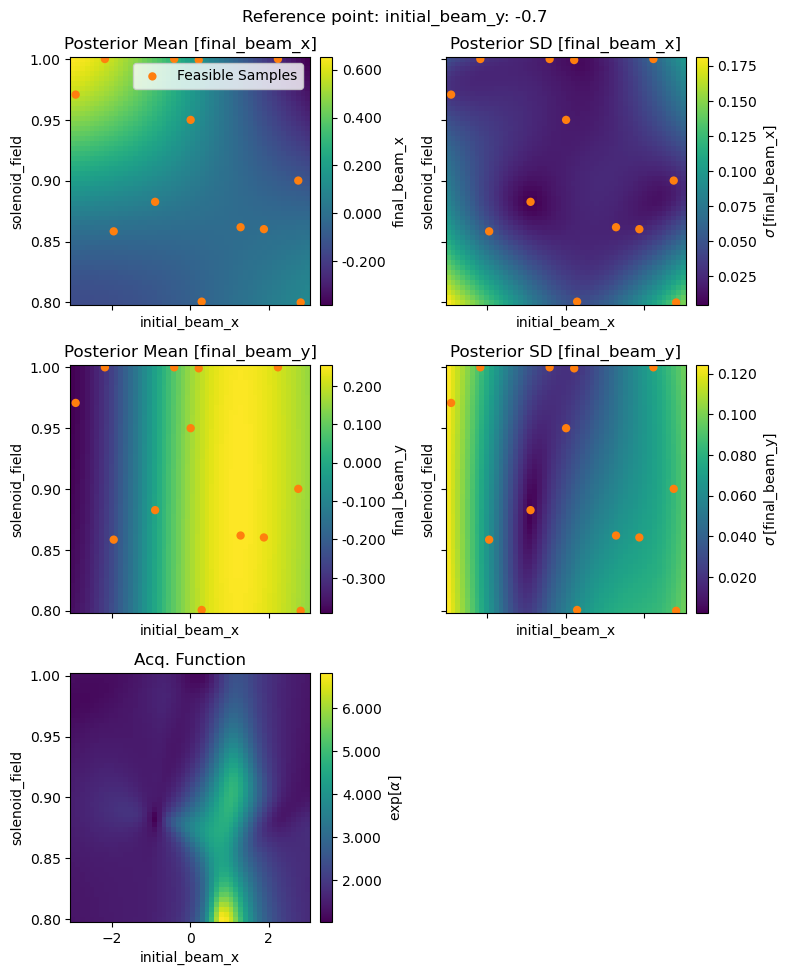

In [14]:
X.generator.visualize_model(variable_names=["initial_beam_x", "solenoid_field"],
                           reference_point=reference_point
                           )

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(<Figure size 800x990 with 11 Axes>,
 array([[<Axes: title={'center': 'Posterior Mean [final_beam_x]'}, xlabel='initial_beam_y', ylabel='solenoid_field'>,
         <Axes: title={'center': 'Posterior SD [final_beam_x]'}, xlabel='initial_beam_y', ylabel='solenoid_field'>],
        [<Axes: title={'center': 'Posterior Mean [final_beam_y]'}, xlabel='initial_beam_y', ylabel='solenoid_field'>,
         <Axes: title={'center': 'Posterior SD [final_beam_y]'}, xlabel='initial_beam_y', ylabel='solenoid_field'>],
        [<Axes: title={'center': 'Acq. Function'}, xlabel='initial_beam_y', ylabel='solenoid_field'>,
         <Axes: >]], dtype=object))

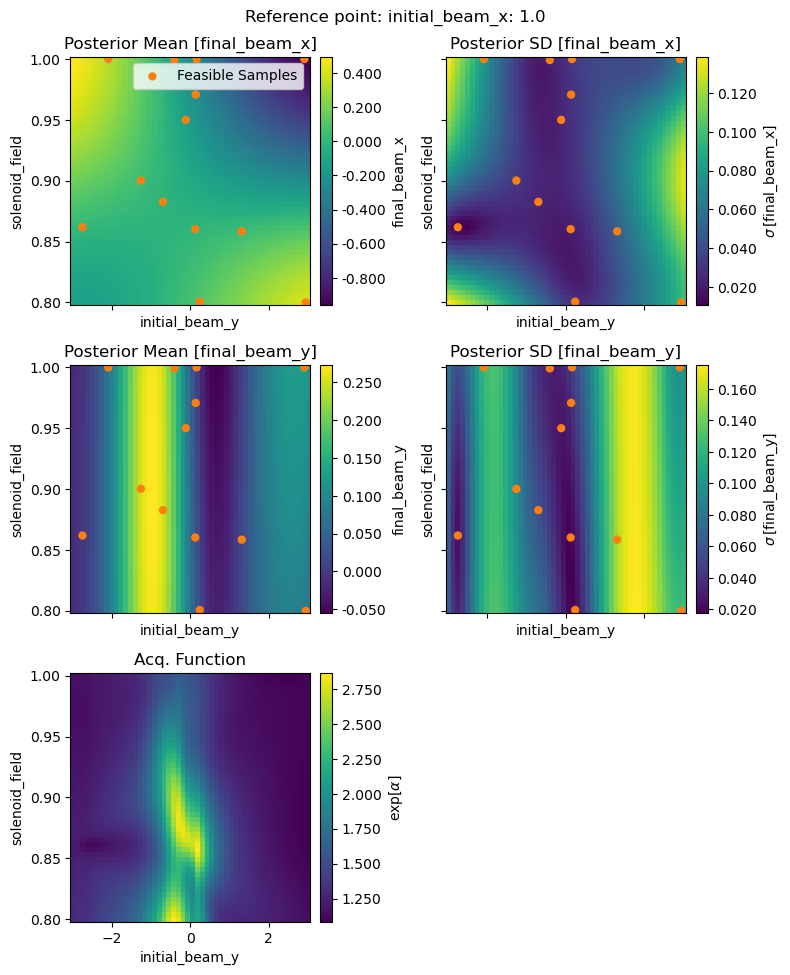

In [15]:
X.generator.visualize_model(variable_names=["initial_beam_y", "solenoid_field"],
                           reference_point=reference_point
                           )

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


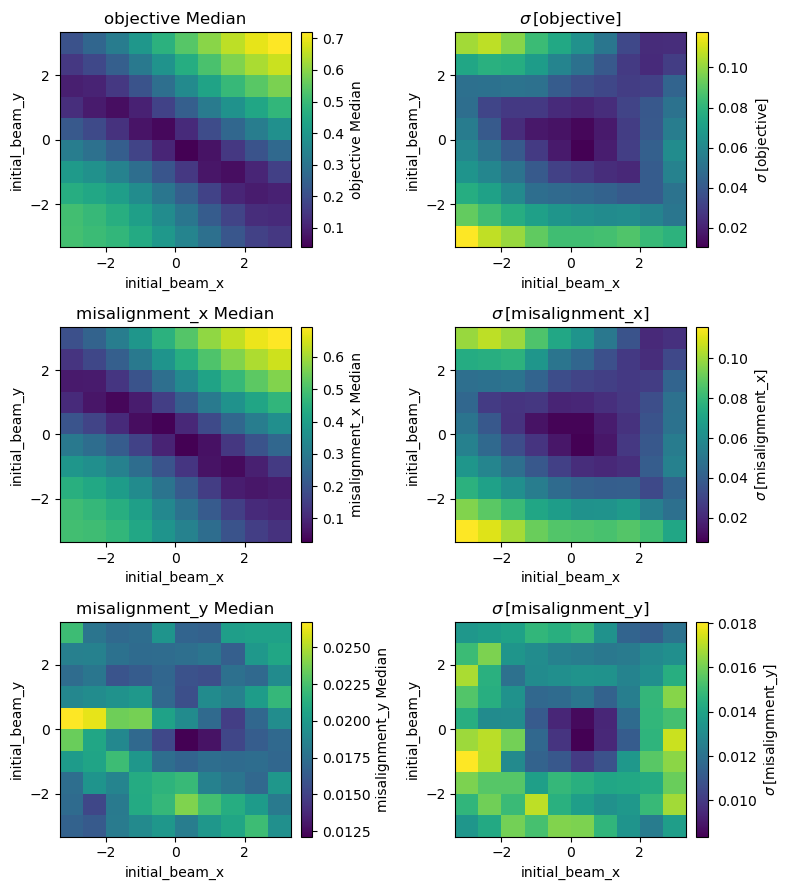

In [16]:
from bax_algorithms.visualize import visualize_virtual_measurement_result

fig, ax = visualize_virtual_measurement_result(
    X.generator,
    variable_names=["initial_beam_x", "initial_beam_y"],
    reference_point=reference_point,
    n_grid=10,
    n_samples=100,
    result_keys=["objective", "misalignment_x", "misalignment_y"]
)

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


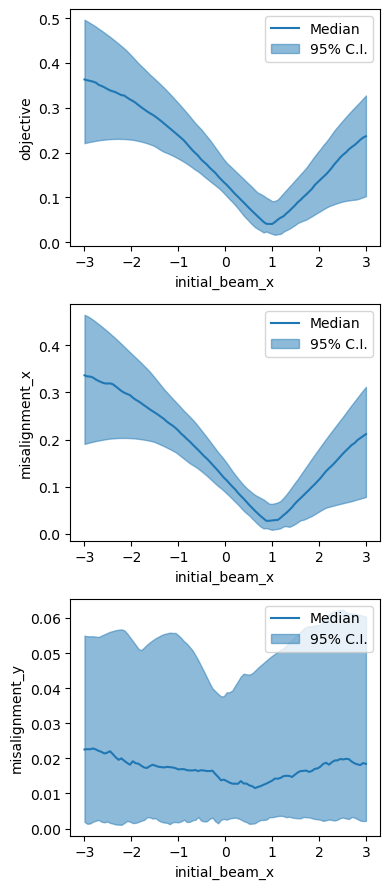

In [17]:
from bax_algorithms.visualize import visualize_virtual_measurement_result

fig, ax = visualize_virtual_measurement_result(
    X.generator,
    variable_names=["initial_beam_x"],
    reference_point=reference_point,
    n_grid=100,
    n_samples=100,
    result_keys=["objective", "misalignment_x", "misalignment_y"]
)

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


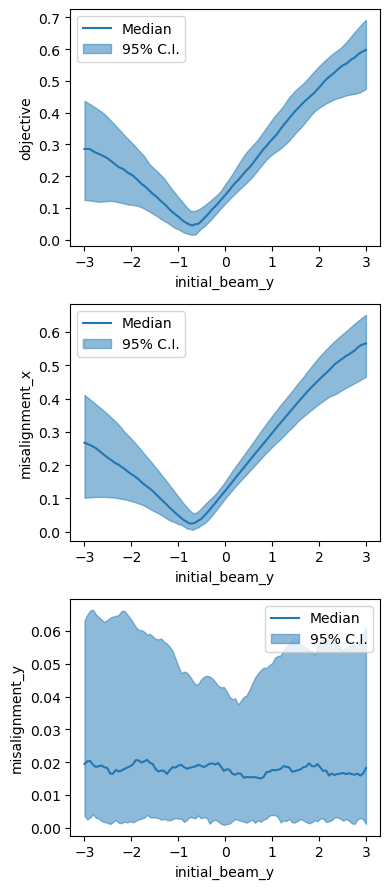

In [18]:
from bax_algorithms.visualize import visualize_virtual_measurement_result

fig, ax = visualize_virtual_measurement_result(
    X.generator,
    variable_names=["initial_beam_y"],
    reference_point=reference_point,
    n_grid=100,
    n_samples=100,
    result_keys=["objective", "misalignment_x", "misalignment_y"]
)

In [19]:
for i in range(5):
    print(i)
    start = time.time()
    X.step()
    print(time.time() - start)

0


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


2.458513021469116
1


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


2.3751838207244873
2


...

2.2532317638397217
3


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


2.724370002746582
4


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


2.7166831493377686


In [20]:
x_tuning = get_bax_mean_prediction(X.generator, mean_optimizer)
x_tuning_dict = tuning_input_tensor_to_dict(X.generator, x_tuning)
print(x_tuning)
print(x_tuning_dict)
reference_point = x_tuning_dict | {"solenoid_field":0.}
print(reference_point)

Beginning BAX virtual optimization.


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


BAX virtual optimization took: 0.3114335536956787 seconds.
tensor([[-0.0143, -0.0171]])
{'initial_beam_x': -0.014282143873079689, 'initial_beam_y': -0.017118035482437954}
{'initial_beam_x': -0.014282143873079689, 'initial_beam_y': -0.017118035482437954, 'solenoid_field': 0.0}


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(<Figure size 800x990 with 11 Axes>,
 array([[<Axes: title={'center': 'Posterior Mean [final_beam_x]'}, xlabel='initial_beam_x', ylabel='solenoid_field'>,
         <Axes: title={'center': 'Posterior SD [final_beam_x]'}, xlabel='initial_beam_x', ylabel='solenoid_field'>],
        [<Axes: title={'center': 'Posterior Mean [final_beam_y]'}, xlabel='initial_beam_x', ylabel='solenoid_field'>,
         <Axes: title={'center': 'Posterior SD [final_beam_y]'}, xlabel='initial_beam_x', ylabel='solenoid_field'>],
        [<Axes: title={'center': 'Acq. Function'}, xlabel='initial_beam_x', ylabel='solenoid_field'>,
         <Axes: >]], dtype=object))

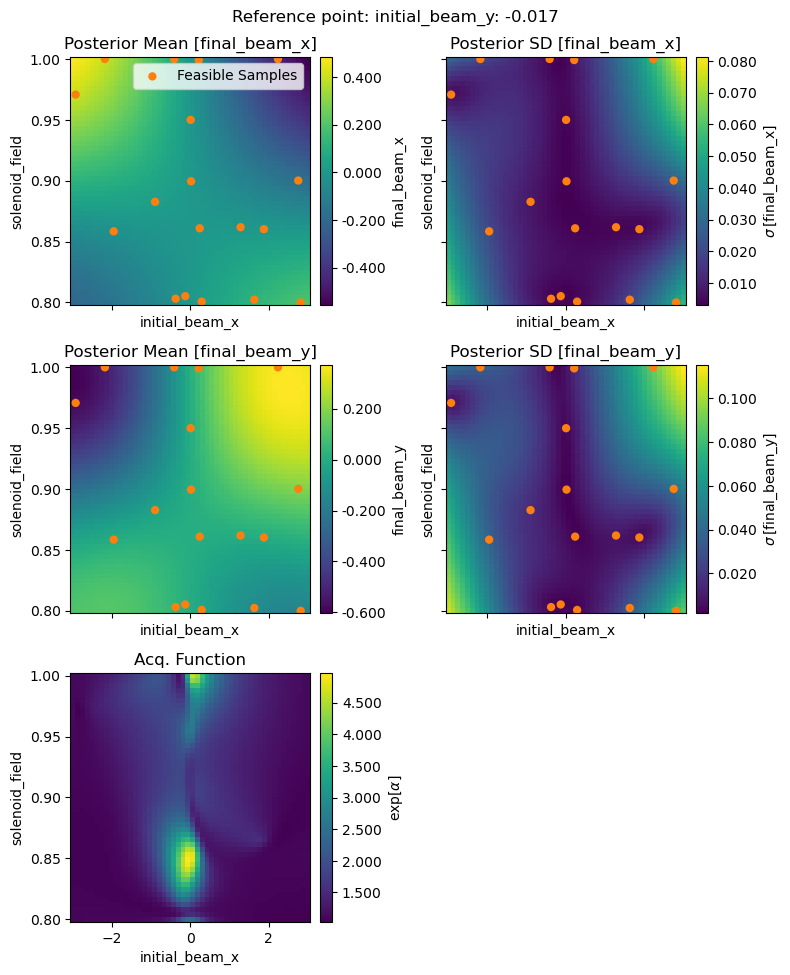

In [21]:
X.generator.visualize_model(variable_names=["initial_beam_x", "solenoid_field"],
                           reference_point=reference_point
                           )

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(<Figure size 800x990 with 11 Axes>,
 array([[<Axes: title={'center': 'Posterior Mean [final_beam_x]'}, xlabel='initial_beam_y', ylabel='solenoid_field'>,
         <Axes: title={'center': 'Posterior SD [final_beam_x]'}, xlabel='initial_beam_y', ylabel='solenoid_field'>],
        [<Axes: title={'center': 'Posterior Mean [final_beam_y]'}, xlabel='initial_beam_y', ylabel='solenoid_field'>,
         <Axes: title={'center': 'Posterior SD [final_beam_y]'}, xlabel='initial_beam_y', ylabel='solenoid_field'>],
        [<Axes: title={'center': 'Acq. Function'}, xlabel='initial_beam_y', ylabel='solenoid_field'>,
         <Axes: >]], dtype=object))

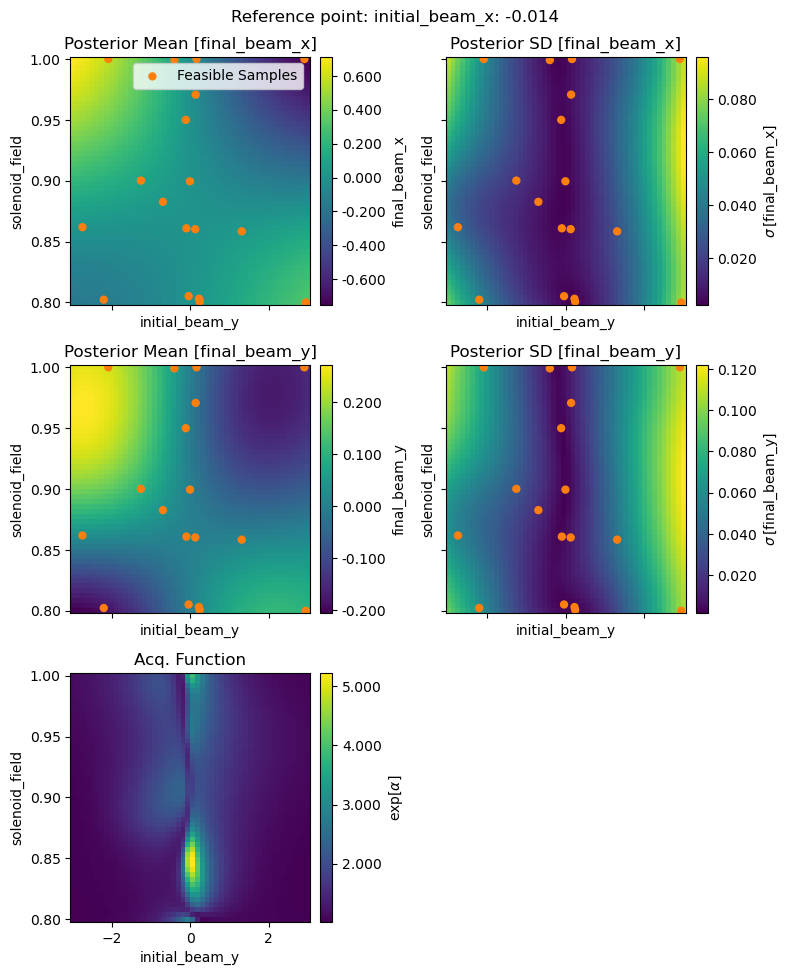

In [22]:
X.generator.visualize_model(variable_names=["initial_beam_y", "solenoid_field"],
                           reference_point=reference_point
                           )

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


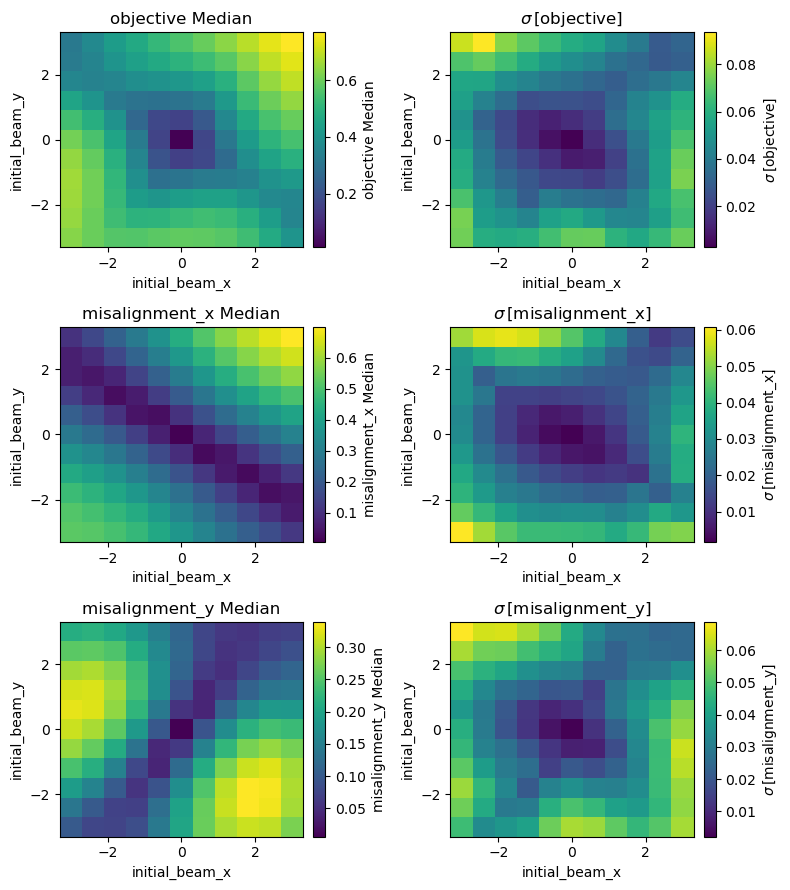

In [23]:
from bax_algorithms.visualize import visualize_virtual_measurement_result

fig, ax = visualize_virtual_measurement_result(
    X.generator,
    variable_names=["initial_beam_x", "initial_beam_y"],
    reference_point=reference_point,
    n_grid=11,
    n_samples=100,
    result_keys=["objective", "misalignment_x", "misalignment_y"]
)

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


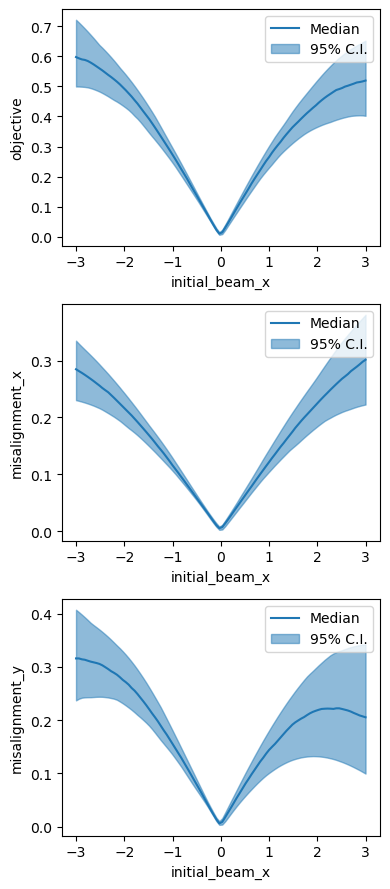

In [24]:
from bax_algorithms.visualize import visualize_virtual_measurement_result

fig, ax = visualize_virtual_measurement_result(
    X.generator,
    variable_names=["initial_beam_x"],
    reference_point=reference_point,
    n_grid=100,
    n_samples=100,
    result_keys=["objective", "misalignment_x", "misalignment_y"]
)

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


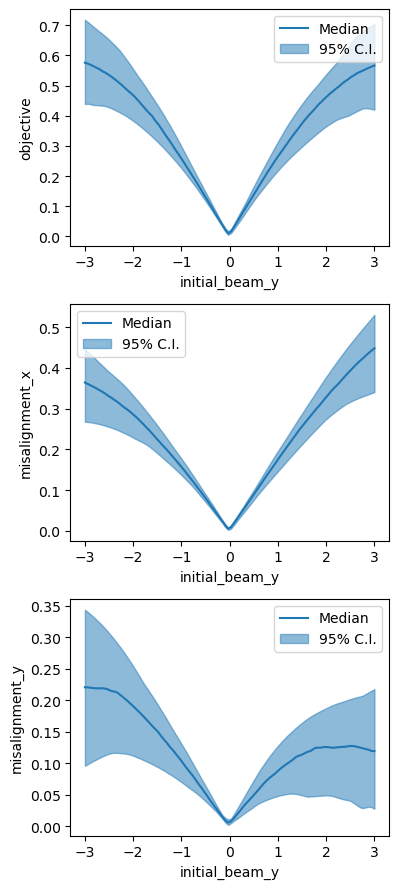

In [25]:
from bax_algorithms.visualize import visualize_virtual_measurement_result

fig, ax = visualize_virtual_measurement_result(
    X.generator,
    variable_names=["initial_beam_y"],
    reference_point=reference_point,
    n_grid=100,
    n_samples=100,
    result_keys=["objective", "misalignment_x", "misalignment_y"]
)